In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# Baseline flat LCDM cosmology used for Fig. 1 in the paper.
H0 = 70.0  # km/s/Mpc
OMEGA_M = 0.275
OMEGA_B = 0.046
OMEGA_LAMBDA = 1.0 - OMEGA_M
C_LIGHT = 299792.458  # km/s

# Eq. (2) prefactor. It cancels in peak-normalized plots, but keeping it
# makes q_i the physical lensing efficiency kernel.
LENSING_PREFACTOR = 1.5 * OMEGA_M * (H0 / C_LIGHT) ** 2


In [2]:
# Redshift grid for evaluating source distributions and lensing kernels.
z_grid = np.linspace(0.001, 4.0, 2000)

# 20-bin analogue of the Stage-IV tomographic examples in Fig. 1.
# The original request used sources between z = 0.1 and z = 2.0,
# so this keeps that range while using the paper's tomographic construction.
n_bins = 20
z_min = 0.1
z_max = 2.0

# Eq. (13): n(z) proportional to (z/z_e)^2 exp[-(z/z_e)^(3/2)].
z_e = 0.9 / np.sqrt(2.0)

# Set to 0.0 for the perfect-redshift case, corresponding to the right
# column of Fig. 1. Set to 0.05 for the photo-z-smoothed middle column.
photo_z_sigma0 = 0.0


In [3]:
def stage_iv_nz_unnormalized(z):
    """
    Source population from Eq. (13) of the paper.
    """
    z = np.asarray(z)
    nz = (z / z_e) ** 2 * np.exp(-((z / z_e) ** 1.5))
    return np.where(z >= 0.0, nz, 0.0)


def normalize_over_z(nz):
    """
    Normalize a redshift distribution so integral n(z) dz = 1.
    """
    norm = integrate.trapezoid(nz, z_grid)
    if norm <= 0.0:
        return nz
    return nz / norm


# Parent source distribution used to define equal-number tomographic bins.
parent_nz = normalize_over_z(stage_iv_nz_unnormalized(z_grid))
parent_cdf = integrate.cumulative_trapezoid(parent_nz, z_grid, initial=0.0)

# Equal-number bins over the requested redshift range.
cdf_min = np.interp(z_min, z_grid, parent_cdf)
cdf_max = np.interp(z_max, z_grid, parent_cdf)
z_edges = np.interp(
    np.linspace(cdf_min, cdf_max, n_bins + 1),
    parent_cdf,
    z_grid,
)
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

# Optional Eq. (14) photo-z smoothing kernel.
photo_z_kernel_matrix = None
if photo_z_sigma0 > 0.0:
    sigma_true = photo_z_sigma0 * (1.0 + z_grid)
    photo_z_kernel_matrix = np.exp(
        -0.5 * ((z_grid[:, None] - z_grid[None, :]) / sigma_true[None, :]) ** 2
    ) / (np.sqrt(2.0 * np.pi) * sigma_true[None, :])

n_of_z = np.zeros((n_bins, len(z_grid)))

for i in range(n_bins):
    in_bin = (z_grid >= z_edges[i]) & (z_grid < z_edges[i + 1])
    if i == n_bins - 1:
        in_bin = (z_grid >= z_edges[i]) & (z_grid <= z_edges[i + 1])

    nz_true_bin = np.where(in_bin, parent_nz, 0.0)

    if photo_z_kernel_matrix is not None:
        # Eq. (14): smooth the true-redshift bin distribution by p(z|z').
        nz = integrate.trapezoid(
            photo_z_kernel_matrix * nz_true_bin[None, :],
            z_grid,
            axis=1,
        )
    else:
        nz = nz_true_bin

    n_of_z[i] = normalize_over_z(nz)

print("Tomographic bin edges:")
for i in range(n_bins):
    print(f"bin {i + 1}: {z_edges[i]:.3f} < z < {z_edges[i + 1]:.3f}")


Tomographic bin edges:
bin 1: 0.100 < z < 0.321
bin 2: 0.321 < z < 0.416
bin 3: 0.416 < z < 0.491
bin 4: 0.491 < z < 0.555
bin 5: 0.555 < z < 0.614
bin 6: 0.614 < z < 0.670
bin 7: 0.670 < z < 0.724
bin 8: 0.724 < z < 0.778
bin 9: 0.778 < z < 0.831
bin 10: 0.831 < z < 0.886
bin 11: 0.886 < z < 0.942
bin 12: 0.942 < z < 1.000
bin 13: 1.000 < z < 1.062
bin 14: 1.062 < z < 1.129
bin 15: 1.129 < z < 1.202
bin 16: 1.202 < z < 1.285
bin 17: 1.285 < z < 1.382
bin 18: 1.382 < z < 1.504
bin 19: 1.504 < z < 1.675
bin 20: 1.675 < z < 2.000


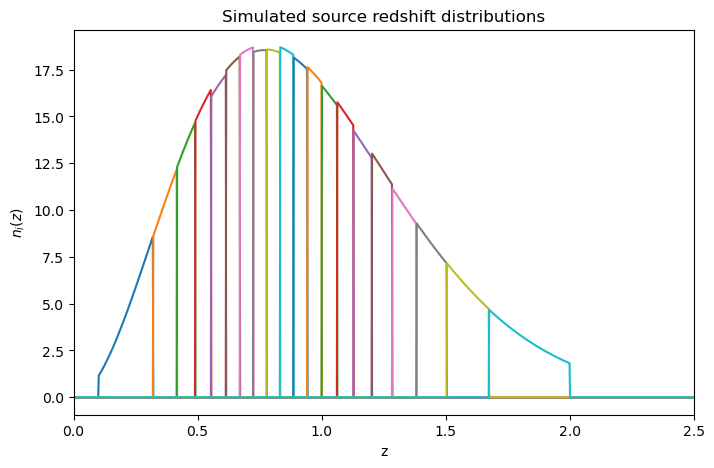

In [4]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, n_of_z[i])

plt.xlabel("z")
plt.ylabel(r"$n_i(z)$")
plt.title("Simulated source redshift distributions")
plt.xlim(0, 2.5)
plt.show()

In [5]:
def E_of_z(z):
    """
    Dimensionless expansion rate for the flat LCDM background used in Fig. 1.
    """
    return np.sqrt(OMEGA_M * (1.0 + z) ** 3 + OMEGA_LAMBDA)


# Build chi(z) by integrating c/H0 * int dz/E(z) from z=0.
z_grid_for_chi = np.concatenate(([0.0], z_grid))
chi_grid_for_chi = (C_LIGHT / H0) * integrate.cumulative_trapezoid(
    1.0 / E_of_z(z_grid_for_chi),
    z_grid_for_chi,
    initial=0.0,
)


def chi_of_z(z):
    """
    Comoving distance chi(z) in Mpc for the flat background cosmology.
    """
    return np.interp(z, z_grid_for_chi, chi_grid_for_chi)


chi_grid = chi_of_z(z_grid)


In [6]:
def reverse_cumulative_trapezoid(y, x):
    """
    Return int_x^xmax y(x') dx' evaluated at each grid point.
    """
    return -integrate.cumulative_trapezoid(y[::-1], x[::-1], initial=0.0)[::-1]


q = np.zeros_like(n_of_z)
q_plot = np.zeros_like(n_of_z)

for i in range(n_bins):
    # Eq. (2), using n_i(z) dz = n_i(chi) dchi.
    tail_n = reverse_cumulative_trapezoid(n_of_z[i], z_grid)
    tail_n_over_chi = reverse_cumulative_trapezoid(n_of_z[i] / chi_grid, z_grid)

    q_i = (
        LENSING_PREFACTOR
        * chi_grid
        * (1.0 + z_grid)
        * (tail_n - chi_grid * tail_n_over_chi)
    )

    # The exact integral is non-negative; this removes roundoff at the boundary.
    q_i = np.where(q_i > 0.0, q_i, 0.0)
    q[i] = q_i

    # Peak normalization is only for plotting, matching Fig. 1.
    max_q = np.max(q_i)
    if max_q > 0.0:
        q_plot[i] = q_i / max_q


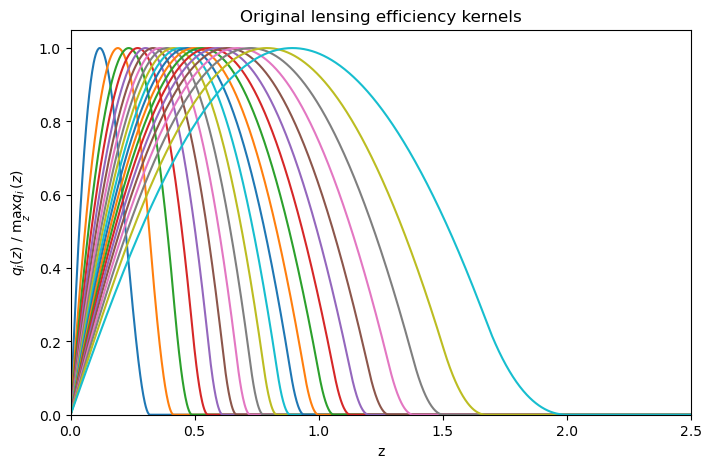

In [7]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, q_plot[i])

plt.xlabel("z")
plt.ylabel(r"$q_i(z)$ / $\max_z q_i(z)$")
plt.title("Original lensing efficiency kernels")
plt.xlim(0, 2.5)
plt.ylim(0, 1.05)
plt.show()


In [8]:
B = np.zeros(n_bins)

for i in range(n_bins):
    # Eq. (18): B_i = int dz n_i(z) / chi(z).
    B[i] = integrate.trapezoid(n_of_z[i] / chi_grid, z_grid)

print("B coefficients:")
print(B)


B coefficients:
[0.00109469 0.00068875 0.0005723  0.00050549 0.00045904 0.0004238
 0.0003959  0.00037256 0.00035242 0.00033487 0.00031918 0.00030484
 0.00029152 0.00027896 0.00026686 0.00025504 0.00024319 0.00023083
 0.00021727 0.00020025]


In [9]:
def build_bnt_matrix_from_B(B):
    """
    Build the BNT matrix using the two nulling conditions:

        sum_j M_ij = 0

    and

        sum_j M_ij B_j = 0

    for each row i, using the three neighboring bins:
        i-2, i-1, i

    We set M_ii = 1 and solve for M_i,i-2 and M_i,i-1.
    """
    n = len(B)
    M = np.zeros((n, n))

    # First bin is left unchanged.
    M[0, 0] = 1.0

    # Second bin is a simple difference because true three-bin nulling
    # starts only from the third bin.
    M[1, 0] = -1.0
    M[1, 1] = 1.0

    for i in range(2, n):
        a = (B[i - 1] - B[i]) / (B[i - 2] - B[i - 1])
        b = -1.0 - a

        M[i, i - 2] = a
        M[i, i - 1] = b
        M[i, i] = 1.0

    return M


M = build_bnt_matrix_from_B(B)

print("BNT matrix shape:", M.shape)

BNT matrix shape: (20, 20)


In [10]:
# Eq. (15): apply the BNT transformation to the physical,
# unnormalized lensing efficiency kernels.
q_tilde = M @ q


In [11]:
# Normalize the transformed kernels by their positive peak for plotting,
# matching the lower panels of Fig. 1.
q_tilde_plot = np.zeros_like(q_tilde)

for i in range(n_bins):
    max_q_tilde = np.max(q_tilde[i])

    if max_q_tilde > 0.0:
        q_tilde_plot[i] = q_tilde[i] / max_q_tilde


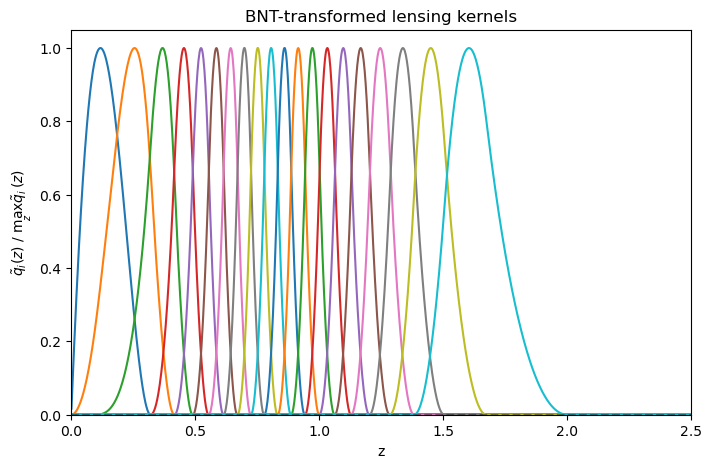

In [12]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, q_tilde_plot[i])

plt.xlabel("z")
plt.ylabel(r"$\tilde{q}_i(z)$ / $\max_z \tilde{q}_i(z)$")
plt.title("BNT-transformed lensing kernels")

plt.xlim(0, 2.5)
y_min = min(0.0, np.min(q_tilde_plot))
plt.ylim(1.05 * y_min if y_min < 0.0 else 0.0, 1.05)

plt.axhline(
    0,
    color="k",
    linestyle="--",
    alpha=0.4,
)

plt.show()


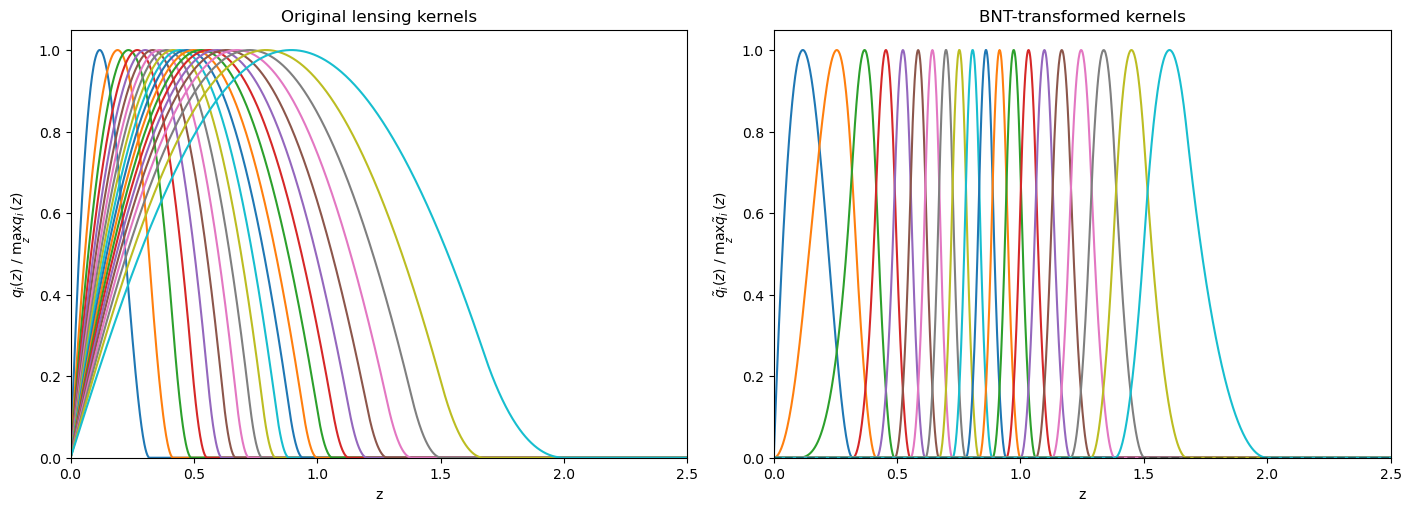

In [13]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    constrained_layout=True,
)

# Original kernels, normalized only for plotting.
for i in range(n_bins):
    axs[0].plot(z_grid, q_plot[i])

axs[0].set_title("Original lensing kernels")
axs[0].set_xlabel("z")
axs[0].set_ylabel(r"$q_i(z)$ / $\max_z q_i(z)$")
axs[0].set_xlim(0, 2.5)
axs[0].set_ylim(0, 1.05)

# BNT-transformed kernels, normalized only for plotting.
for i in range(n_bins):
    axs[1].plot(z_grid, q_tilde_plot[i])

axs[1].set_title("BNT-transformed kernels")
axs[1].set_xlabel("z")
axs[1].set_ylabel(r"$\tilde{q}_i(z)$ / $\max_z \tilde{q}_i(z)$")

axs[1].set_xlim(0, 2.5)
y_min = min(0.0, np.min(q_tilde_plot))
axs[1].set_ylim(1.05 * y_min if y_min < 0.0 else 0.0, 1.05)

axs[1].axhline(
    0,
    color="k",
    linestyle="--",
    alpha=0.4,
)

plt.show()


## Corrections made in this version

- Instead of using simple Gaussian source bins, the notebook now follows the source galaxy distribution used in the paper (Eq. 13). This distribution is divided into 20 tomographic bins with approximately equal numbers of galaxies between the chosen redshift limits. Setting `photo_z_sigma0 = 0.05` adds the photometric redshift smoothing from Eq. (14) (the middle column of Figure 1), while `photo_z_sigma0 = 0.0` gives the perfect-redshift case (the right column of Figure 1).

- The lensing kernels now follow the full expression from Eq. (2) of the paper. This includes both the cosmological prefactor, `(3/2) * Omega_m * (H0/c)^2`, and the `1/a(chi) = 1 + z` term that was missing before.

- The original lensing kernels are no longer normalized before applying the BNT transformation. The BNT matrix is now applied to the physical (unnormalized) kernels, which matches the procedure described in the paper. The normalized arrays (`q_plot` and `q_tilde_plot`) are only used when making the figures.

- The BNT transformation matrix is still constructed using Eqs. (18)–(20). The coefficients are calculated from the quantities `B_i = ∫ n_i(z) / χ(z) dz`, with the diagonal elements fixed to `M_ii = 1`.

In [14]:
print("BNT nulling checks for rows i >= 2:")
print("max |sum_j M_ij|       =", np.max(np.abs(M[2:].sum(axis=1))))
print("max |sum_j M_ij B_j|   =", np.max(np.abs(M[2:] @ B)))
print("min normalized q_tilde =", np.min(q_tilde_plot))
print("max normalized q_tilde =", np.max(q_tilde_plot))


BNT nulling checks for rows i >= 2:
max |sum_j M_ij|       = 2.220446049250313e-16
max |sum_j M_ij B_j|   = 1.0842021724855044e-19
min normalized q_tilde = -1.9654148504731198e-14
max normalized q_tilde = 1.0
